## Select the Right Threshold values using ROC Curve
+ https://github.com/krishnaik06/SVM-kernel-and-ROC-AUC-Curve/blob/main/ROCAUC.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# roc curve and auc score
from sklearn.datasets import make_classification

In [3]:
from sklearn.model_selection import train_test_split
X, y = make_classification3(n_samples=2000, n_classes=2, weights=[1, 1], random_state=1)

In [4]:
X.shape

(2000, 20)

In [5]:
y

array([0, 0, 0, ..., 1, 1, 0])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [8]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

#### Random Forests

In [10]:
# Apply RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
ytrain_pred = rf.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf.predict_proba(X_test)
print('RF test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

RF train roc-auc: 1.0
RF test roc-auc: 0.9822388888888889


In [11]:
ytrain_pred

array([[1.  , 0.  ],
       [0.99, 0.01],
       [0.01, 0.99],
       ...,
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.31, 0.69]])

#### Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
log_classifier=LogisticRegression()
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Logistic train roc-auc: 0.9863568922694498
Logistic test roc-auc: 0.9885777777777777


#### Adaboost Classifier

In [16]:
from sklearn.ensemble import AdaBoostClassifier
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.9975081174960356
Adaboost test roc-auc: 0.9826111111111111


#### KNN Classifier

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.981670071491109
Adaboost test roc-auc: 0.9426111111111111


#### Selecting best threshold for maximum accuracy (RF)

In [ ]:
# for each model, predict probability, append output into list, and concatenate to dataframe.

In [22]:
pred=[]
for model in [rf, log_classifier, ada_classifier, knn_classifier]:
    pred.append(pd.Series(model.predict_proba(X_test)[:,1]))
final_prediction=pd.concat(pred,axis=1).mean(axis=1)
print('Ensemble test roc-auc: {}'.format(roc_auc_score(y_test,final_prediction)))

Ensemble test roc-auc: 0.9850555555555556


In [24]:
pred

[0      0.99
 1      0.00
 2      0.97
 3      0.95
 4      0.52
        ... 
 595    0.00
 596    0.04
 597    0.99
 598    0.00
 599    1.00
 Length: 600, dtype: float64,
 0      0.991861
 1      0.000008
 2      0.966929
 3      0.761539
 4      0.779443
          ...   
 595    0.024239
 596    0.000003
 597    0.984385
 598    0.001147
 599    0.989540
 Length: 600, dtype: float64,
 0      0.559186
 1      0.463282
 2      0.538202
 3      0.509875
 4      0.490344
          ...   
 595    0.461121
 596    0.441377
 597    0.532403
 598    0.441720
 599    0.559890
 Length: 600, dtype: float64,
 0      1.0
 1      0.0
 2      0.8
 3      0.8
 4      0.4
       ... 
 595    0.0
 596    0.0
 597    1.0
 598    0.2
 599    0.8
 Length: 600, dtype: float64]

In [23]:
pd.concat(pred, axis=1)

,0,1,2,3
0,0.99,0.991861,0.559186,1.0
1,0.00,0.000008,0.463282,0.0
2,0.97,0.966929,0.538202,0.8
3,0.95,0.761539,0.509875,0.8
4,0.52,0.779443,0.490344,0.4
...,...,...,...,...
595,0.00,0.024239,0.461121,0.0
596,0.04,0.000003,0.441377,0.0
597,0.99,0.984385,0.532403,1.0
598,0.00,0.001147,0.441720,0.2


In [25]:
final_prediction

0      0.885262
1      0.115823
2      0.818783
3      0.755353
4      0.547447
         ...   
595    0.121340
596    0.120345
597    0.876697
598    0.160717
599    0.837357
Length: 600, dtype: float64

#### Calculate ROC Curve

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, final_prediction)
thresholds

array([       inf, 0.91188114, 0.90406694, 0.90327475, 0.79556516,
       0.7955558 , 0.79225303, 0.79071156, 0.75803202, 0.75787124,
       0.72975181, 0.72887362, 0.72869595, 0.72643711, 0.67513034,
       0.67243537, 0.60962652, 0.59175354, 0.5890152 , 0.58800386,
       0.58245356, 0.58114346, 0.58088469, 0.57736186, 0.57396627,
       0.56469563, 0.56042732, 0.55139283, 0.54105932, 0.53127948,
       0.53115858, 0.49366892, 0.4371034 , 0.39318654, 0.39129719,
       0.35495613, 0.34336612, 0.24573004, 0.24396893, 0.24154122,
       0.23890421, 0.20713088, 0.20098417, 0.12034501, 0.1203351 ,
       0.10632697])

In [27]:
from sklearn.metrics import accuracy_score
accuracy_ls = []
for thres in thresholds:
    y_pred = np.where(final_prediction>thres,1,0)
    accuracy_ls.append(accuracy_score(y_test, y_pred, normalize=True))
    
accuracy_ls = pd.concat([pd.Series(thresholds), pd.Series(accuracy_ls)],
                        axis=1)
accuracy_ls.columns = ['thresholds', 'accuracy']
accuracy_ls.sort_values(by='accuracy', ascending=False, inplace=True)
accuracy_ls.head()

,thresholds,accuracy
32,0.437103,0.961667
31,0.493669,0.958333
29,0.531279,0.958333
30,0.531159,0.956667
28,0.541059,0.956667


In [28]:
# use threshold value with the highest accuracy

accuracy_ls

,thresholds,accuracy
32,0.437103,0.961667
31,0.493669,0.958333
29,0.531279,0.958333
30,0.531159,0.956667
28,0.541059,0.956667
27,0.551393,0.955000
26,0.560427,0.953333
25,0.564696,0.951667
23,0.577362,0.950000
24,0.573966,0.950000


In [29]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

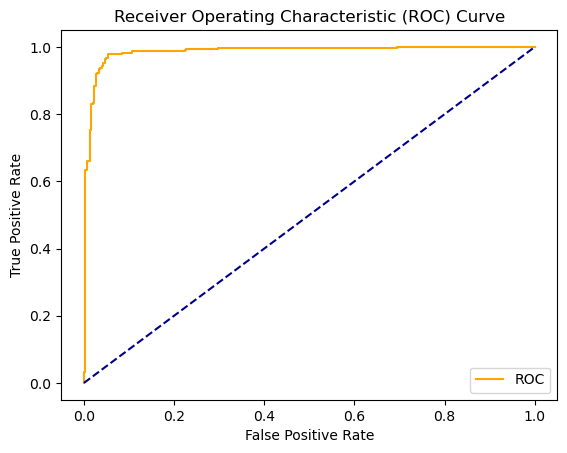

In [30]:
plot_roc_curve(fpr,tpr)